In [1]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import pickle # For serializing and deserializing Python objects
from sklearn.metrics import roc_auc_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sys
sys.path.append("/home/suraj/Repositories/TumorImagingBench/notebooks/modelling")

from modelling_utils import (
    train_knn_classifier, evaluate_model,
    train_linear_probing_classifier,
    train_few_shot_classifier,
    build_knn_ensemble_classifier, predict_with_ensemble,
    train_stacking_ensemble_classifier, predict_with_stacking_ensemble,
    plot_model_comparison, extract_model_features, 
    compute_knn_indices, compute_overlap_matrix, plot_overlap_matrix, 
    split_shuffle_data, apply_r_style
)
from pathlib import Path

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_SLUG = 'luna'
FIG_SIZE = 900


In [2]:
# Load features from a pickle file
feature_dict_path = "/home/suraj/Repositories/TumorImagingBench/data/features/luna.pkl" # Path to the pickle file containing features
with open(feature_dict_path, 'rb') as file: # Open the file in read binary mode
    data = pickle.load(file) # Load the data from the pickle file

data.pop("DummyResNetExtractor")

{'train': [{'feature': array([[0.76501995, 0.75426483, 0.7935326 , 0.8791282 , 0.7518093 ,
           0.7315222 , 0.8546515 , 0.7794672 , 0.8389575 , 0.7741631 ,
           0.9197193 , 0.9305369 , 0.86175454, 0.9474826 , 0.83955145,
           0.7254511 , 0.8919679 , 0.8064276 , 0.91725564, 1.003192  ,
           0.866873  , 0.72104454, 0.76662797, 0.8565486 , 0.76568663,
           0.83619416, 0.779988  , 0.8120089 , 0.90895915, 1.0059377 ,
           0.7504225 , 0.7086251 , 0.9544165 , 0.8218791 , 0.7953693 ,
           0.6996136 , 0.7917068 , 0.98301613, 0.74825907, 0.88593066,
           0.8355644 , 0.82172024, 0.7937584 , 0.85542864, 0.77535504,
           0.83959585, 0.7365528 , 0.7643509 , 1.0024995 , 0.7225963 ,
           0.88357   , 0.74803996, 0.81797695, 0.78934604, 0.71019095,
           0.8373338 , 0.8269481 , 0.7700001 , 0.66514105, 0.78532225,
           0.76682544, 0.79394746, 0.9121032 , 0.83092034, 0.744175  ,
           0.7664347 , 0.8620292 , 0.82259876, 0.7867412 

In [4]:
# Initialize shared variables
model_names = list(data.keys())
test_accuracies_dict = {}  # store baseline KNN AUCs with 95% CI


In [ ]:
# Baseline KNN probing across models
label_key = "malignancy"
for model_name, values in data.items():
    # Extract labels
    train_labels = [v["row"][label_key] for v in values["train"]]
    val_labels = [v["row"][label_key] for v in values["val"]]
    test_labels = [v["row"][label_key] for v in values["test"]]

    # Stack features
    train_items = np.vstack([v["feature"] for v in values["train"]])
    val_items = np.vstack([v["feature"] for v in values["val"]])
    test_items = np.vstack([v["feature"] for v in values["test"]])

    # Combine splits for resampling
    all_items = np.vstack([train_items, val_items, test_items])
    all_labels = train_labels + val_labels + test_labels

    # Average across multiple shuffle splits
    n_splits = 10
    split_scores = []

    for split in range(n_splits):
        train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
            all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10 + split, stratify=True
        )

        best_model, study = train_knn_classifier(train_items_s, train_labels_s, val_items_s, val_labels_s)
        split_score = evaluate_model(best_model, test_items_s, test_labels_s)
        split_scores.append(split_score)

    avg_score = np.mean(split_scores)
    std_error = np.std(split_scores, ddof=1) / np.sqrt(n_splits)
    margin = 1.96 * std_error
    ci_lower = avg_score - margin
    ci_upper = avg_score + margin

    test_accuracies_dict[model_name] = {"mean": avg_score, "ci95": (ci_lower, ci_upper)}
    print(f"{model_name} AUC: {avg_score:.4f} ± {margin:.4f}")


[I 2025-12-03 14:13:33,731] A new study created in memory with name: no-name-29ab4bea-bf63-4e61-a81b-6c6d7c557a8f
[I 2025-12-03 14:13:33,739] Trial 0 finished with value: 0.5047619047619047 and parameters: {'k': 29}. Best is trial 0 with value: 0.5047619047619047.
[I 2025-12-03 14:13:33,745] Trial 1 finished with value: 0.49848484848484853 and parameters: {'k': 12}. Best is trial 0 with value: 0.5047619047619047.
[I 2025-12-03 14:13:33,751] Trial 2 finished with value: 0.5033549783549784 and parameters: {'k': 11}. Best is trial 0 with value: 0.5047619047619047.
[I 2025-12-03 14:13:33,758] Trial 3 finished with value: 0.5301948051948052 and parameters: {'k': 42}. Best is trial 3 with value: 0.5301948051948052.
[I 2025-12-03 14:13:33,764] Trial 4 finished with value: 0.5678571428571428 and parameters: {'k': 3}. Best is trial 4 with value: 0.5678571428571428.
[I 2025-12-03 14:13:33,770] Trial 5 finished with value: 0.5051948051948052 and parameters: {'k': 28}. Best is trial 4 with value: 

CTClipVitExtractor AUC: 0.5726 ± 0.0144


[I 2025-12-03 14:13:38,279] Trial 29 finished with value: 0.6253246753246753 and parameters: {'k': 26}. Best is trial 9 with value: 0.6726190476190477.
[I 2025-12-03 14:13:38,287] Trial 30 finished with value: 0.6461038961038962 and parameters: {'k': 6}. Best is trial 9 with value: 0.6726190476190477.
[I 2025-12-03 14:13:38,296] Trial 31 finished with value: 0.6454545454545455 and parameters: {'k': 18}. Best is trial 9 with value: 0.6726190476190477.
[I 2025-12-03 14:13:38,305] Trial 32 finished with value: 0.6248917748917749 and parameters: {'k': 41}. Best is trial 9 with value: 0.6726190476190477.
[I 2025-12-03 14:13:38,314] Trial 33 finished with value: 0.622077922077922 and parameters: {'k': 50}. Best is trial 9 with value: 0.6726190476190477.
[I 2025-12-03 14:13:38,323] Trial 34 finished with value: 0.6173160173160173 and parameters: {'k': 2}. Best is trial 9 with value: 0.6726190476190477.
[I 2025-12-03 14:13:38,333] Trial 35 finished with value: 0.6309523809523809 and parameters

CTFMExtractor AUC: 0.6543 ± 0.0285


[I 2025-12-03 14:13:42,374] Trial 9 finished with value: 0.8247835497835497 and parameters: {'k': 5}. Best is trial 5 with value: 0.8848484848484848.
[I 2025-12-03 14:13:42,384] Trial 10 finished with value: 0.8834415584415585 and parameters: {'k': 34}. Best is trial 5 with value: 0.8848484848484848.
[I 2025-12-03 14:13:42,395] Trial 11 finished with value: 0.8851731601731602 and parameters: {'k': 36}. Best is trial 11 with value: 0.8851731601731602.
[I 2025-12-03 14:13:42,405] Trial 12 finished with value: 0.8821428571428572 and parameters: {'k': 27}. Best is trial 11 with value: 0.8851731601731602.
[I 2025-12-03 14:13:42,416] Trial 13 finished with value: 0.8853896103896104 and parameters: {'k': 35}. Best is trial 13 with value: 0.8853896103896104.
[I 2025-12-03 14:13:42,426] Trial 14 finished with value: 0.8717532467532468 and parameters: {'k': 19}. Best is trial 13 with value: 0.8853896103896104.
[I 2025-12-03 14:13:42,437] Trial 15 finished with value: 0.8462121212121212 and param

...

SUPREMExtractor AUC: 0.6450 ± 0.0260


[I 2025-12-03 14:14:10,396] Trial 20 finished with value: 0.6977272727272728 and parameters: {'k': 16}. Best is trial 9 with value: 0.7186147186147187.
[I 2025-12-03 14:14:10,408] Trial 21 finished with value: 0.6502164502164502 and parameters: {'k': 31}. Best is trial 9 with value: 0.7186147186147187.
[I 2025-12-03 14:14:10,420] Trial 22 finished with value: 0.6415584415584416 and parameters: {'k': 33}. Best is trial 9 with value: 0.7186147186147187.
[I 2025-12-03 14:14:10,432] Trial 23 finished with value: 0.7 and parameters: {'k': 17}. Best is trial 9 with value: 0.7186147186147187.
[I 2025-12-03 14:14:10,444] Trial 24 finished with value: 0.6323593073593075 and parameters: {'k': 43}. Best is trial 9 with value: 0.7186147186147187.
[I 2025-12-03 14:14:10,456] Trial 25 finished with value: 0.6716450216450216 and parameters: {'k': 21}. Best is trial 9 with value: 0.7186147186147187.
[I 2025-12-03 14:14:10,470] Trial 26 finished with value: 0.635822510822511 and parameters: {'k': 44}. 

VISTA3DExtractor AUC: 0.7111 ± 0.0189


[I 2025-12-03 14:14:16,178] Trial 11 finished with value: 0.5382034632034632 and parameters: {'k': 36}. Best is trial 4 with value: 0.573051948051948.
[I 2025-12-03 14:14:16,192] Trial 12 finished with value: 0.5256493506493507 and parameters: {'k': 27}. Best is trial 4 with value: 0.573051948051948.
[I 2025-12-03 14:14:16,205] Trial 13 finished with value: 0.5295454545454545 and parameters: {'k': 35}. Best is trial 4 with value: 0.573051948051948.
[I 2025-12-03 14:14:16,218] Trial 14 finished with value: 0.5122294372294373 and parameters: {'k': 19}. Best is trial 4 with value: 0.573051948051948.
[I 2025-12-03 14:14:16,231] Trial 15 finished with value: 0.5 and parameters: {'k': 8}. Best is trial 4 with value: 0.573051948051948.
[I 2025-12-03 14:14:16,245] Trial 16 finished with value: 0.5221861471861472 and parameters: {'k': 15}. Best is trial 4 with value: 0.573051948051948.
[I 2025-12-03 14:14:16,259] Trial 17 finished with value: 0.5462121212121211 and parameters: {'k': 46}. Best i

VocoExtractor AUC: 0.5287 ± 0.0301


In [6]:
test_accuracies_dict

{'CTClipVitExtractor': {'mean': 0.5725637325637326,
  'ci95': (0.5581463368798577, 0.5869811282476075)},
 'CTFMExtractor': {'mean': 0.6543097643097643,
  'ci95': (0.6258466733983942, 0.6827728552211344)},
 'FMCIBExtractor': {'mean': 0.8860076960076959,
  'ci95': (0.8715736770355913, 0.9004417149798005)},
 'MerlinExtractor': {'mean': 0.6376430976430976,
  'ci95': (0.62534535058461, 0.6499408447015851)},
 'ModelsGenExtractor': {'mean': 0.806060606060606,
  'ci95': (0.795694502799469, 0.8164267093217431)},
 'PASTAExtractor': {'mean': 0.6647330447330447,
  'ci95': (0.6543163463915026, 0.6751497430745869)},
 'SUPREMExtractor': {'mean': 0.645021645021645,
  'ci95': (0.6190486808571002, 0.6709946091861899)},
 'VISTA3DExtractor': {'mean': 0.711120731120731,
  'ci95': (0.692220769541959, 0.7300206926995031)},
 'VocoExtractor': {'mean': 0.5287061087061088,
  'ci95': (0.49859526021378797, 0.5588169571984296)}}

In [15]:
# Plot test accuracies
fig = plot_model_comparison(test_accuracies_dict, font_size=32, height=FIG_SIZE, width=FIG_SIZE, marker_color="#FCA308")
fig.show() # Show the plot
fig.write_image(PLOTS_DIR / f"luna_auc.png")

In [8]:
from pathlib import Path

if Path("overall_results.csv").exists():
    df = pd.read_csv("overall_results.csv")
else:
    df = pd.DataFrame()

df["Models"] = test_accuracies_dict.keys()
df["LUNA"] = [v["mean"] for k, v in test_accuracies_dict.items()]
df["LUNA_CI_Lower"] = [v["ci95"][0] for k, v in test_accuracies_dict.items()]
df["LUNA_CI_Upper"] = [v["ci95"][1] for k, v in test_accuracies_dict.items()]

df.to_csv("overall_results.csv")

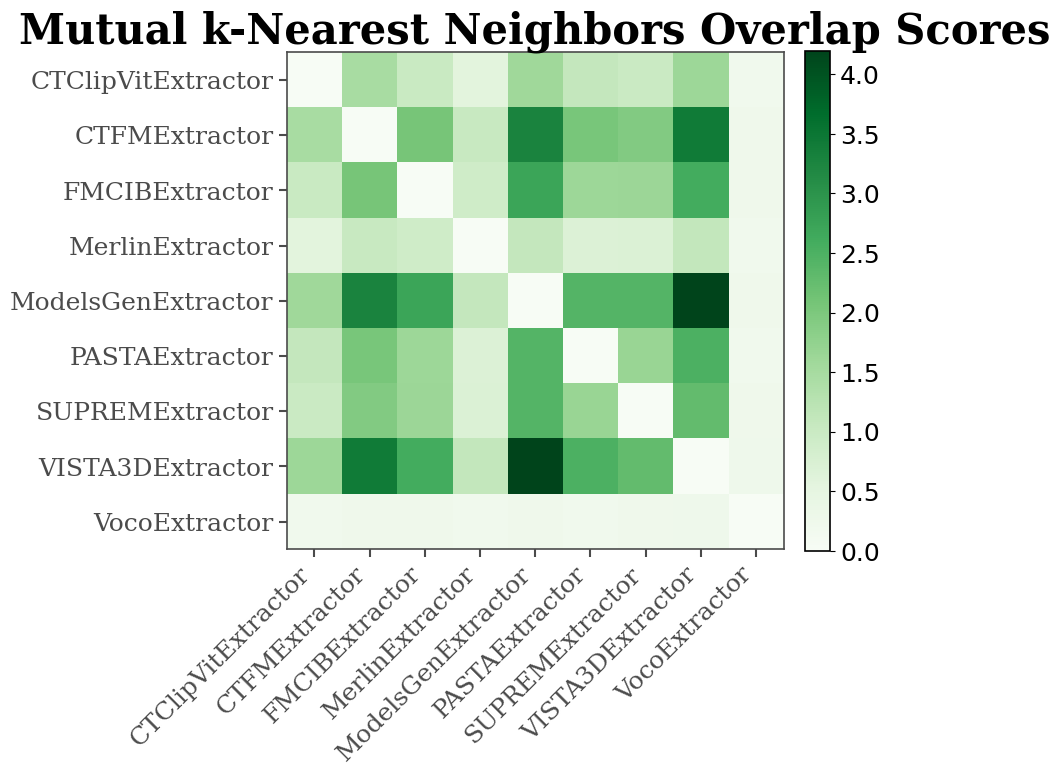

In [16]:
import matplotlib.pyplot as plt

model_features = extract_model_features(data)
model_neighbors = compute_knn_indices(model_features, num_neighbors=10, metric="cosine")
overlap_matrix, model_list = compute_overlap_matrix(model_neighbors)
fig = plot_overlap_matrix(overlap_matrix, model_list, font_size=30, tickangle=45, width=FIG_SIZE, height=FIG_SIZE)
fig.savefig(PLOTS_DIR / f"{DATASET_SLUG}_knn_overlap.png")
plt.show(block=False)

plt.close(fig)

## Linear Probing Evaluation

Evaluate foundation model features using linear probing (logistic regression).
This complements KNN probing and is the standard transfer learning baseline.


In [11]:
# Linear Probing - Train logistic regression on frozen features
linear_probing_results = {}

for model_name, values in data.items():
    print(f"Linear Probing - {model_name}...")
    
    # Extract labels
    train_labels = [v["row"]["malignancy"] for v in values["train"]]
    val_labels = [v["row"]["malignancy"] for v in values["val"]]
    test_labels = [v["row"]["malignancy"] for v in values["test"]]
    
    # Stack features
    train_items = np.vstack([v["feature"] for v in values["train"]])
    val_items = np.vstack([v["feature"] for v in values["val"]])
    test_items = np.vstack([v["feature"] for v in values["test"]])
    
    # Combine all splits
    all_items = np.vstack([train_items, val_items, test_items])
    all_labels = train_labels + val_labels + test_labels
    
    # Average across multiple shuffle splits
    n_splits = 10
    linear_split_scores = []
    
    for split in range(n_splits):
        # Get stratified split
        train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
            all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split, stratify=True
        )
        
        # Train linear probing classifier
        linear_model, _ = train_linear_probing_classifier(train_items_s, train_labels_s, val_items_s, val_labels_s)
        
        # Evaluate on test set
        linear_score = evaluate_model(linear_model, test_items_s, test_labels_s)
        linear_split_scores.append(linear_score)
    
    # Compute statistics
    avg_score = np.mean(linear_split_scores)
    std_error = np.std(linear_split_scores, ddof=1) / np.sqrt(n_splits)
    margin = 1.96 * std_error
    ci_lower = avg_score - margin
    ci_upper = avg_score + margin
    
    linear_probing_results[model_name] = {"mean": avg_score, "ci95": (ci_lower, ci_upper)}
    print(f"  Linear Probing AUC: {avg_score:.4f} ± {margin:.4f}")

print("\n✓ Linear probing evaluation complete")


Linear Probing - CTClipVitExtractor...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

  Linear Probing AUC: 0.5887 ± 0.0192
Linear Probing - CTFMExtractor...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

  Linear Probing AUC: 0.7502 ± 0.0191
Linear Probing - FMCIBExtractor...


...

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

  Linear Probing AUC: 0.8587 ± 0.0107
Linear Probing - VocoExtractor...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

  Linear Probing AUC: 0.5287 ± 0.0215

✓ Linear probing evaluation complete


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



## Few-Shot Learning Evaluation

Evaluate foundation model generalization with limited training data (1-shot, 5-shot, 10-shot).
This assesses how well models work in clinical settings with limited labeled samples.


In [12]:
# Few-Shot Learning - Evaluate with limited training samples
shot_configs = [1, 5, 10]
few_shot_results = {shots: {} for shots in shot_configs}

for model_name, values in data.items():
    print(f"Few-Shot Learning - {model_name}...")
    
    # Extract labels
    train_labels = [v["row"]["malignancy"] for v in values["train"]]
    val_labels = [v["row"]["malignancy"] for v in values["val"]]
    test_labels = [v["row"]["malignancy"] for v in values["test"]]
    
    # Stack features
    train_items = np.vstack([v["feature"] for v in values["train"]])
    val_items = np.vstack([v["feature"] for v in values["val"]])
    test_items = np.vstack([v["feature"] for v in values["test"]])
    
    # Combine all splits
    all_items = np.vstack([train_items, val_items, test_items])
    all_labels = train_labels + val_labels + test_labels
    
    # Evaluate for different shot configurations
    for shots in shot_configs:
        n_splits = 10
        shot_scores = []
        
        for split in range(n_splits):
            # Get stratified split
            train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
                all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split, stratify=True
            )
            
            # Train few-shot model
            np.random.seed(split)
            few_shot_model, _, _ = train_few_shot_classifier(
                train_items_s, train_labels_s,
                val_items_s, val_labels_s,
                shots=shots
            )
            
            # Evaluate on test set
            test_score = evaluate_model(few_shot_model, test_items_s, test_labels_s)
            shot_scores.append(test_score)
        
        # Compute statistics
        mean_score = np.mean(shot_scores)
        std_error = np.std(shot_scores, ddof=1) / np.sqrt(n_splits)
        margin = 1.96 * std_error
        
        few_shot_results[shots][model_name] = {"mean": mean_score, "ci95": (mean_score - margin, mean_score + margin)}
        
        if shots == 1:  # Only print for 1-shot
            print(f"  {shots}-shot AUC: {mean_score:.4f} ± {margin:.4f} ... 10-shot: ", end="")
        elif shots == 10:
            print(f"{few_shot_results[shots][model_name]['mean']:.4f}")

print("\n✓ Few-shot learning evaluation complete")


[I 2025-12-03 14:37:43,205] A new study created in memory with name: no-name-85a88a78-2415-47be-9d85-9f9953efbe61
[I 2025-12-03 14:37:43,213] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:43,217] Trial 1 finished with value: 0.48658008658008656 and parameters: {'k': 1}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:43,226] A new study created in memory with name: no-name-d37ea59a-e1a7-477a-b164-17b17e57d985
[I 2025-12-03 14:37:43,230] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:43,234] Trial 1 finished with value: 0.48744588744588746 and parameters: {'k': 1}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:43,242] A new study created in memory with name: no-name-11e2d2d6-bbde-4e5e-a357-42acec896ad1
[I 2025-12-03 14:37:43,246] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:43,249

Few-Shot Learning - CTClipVitExtractor...
  1-shot AUC: 0.4961 ± 0.0068 ... 10-shot: 

[I 2025-12-03 14:37:43,366] Trial 4 finished with value: 0.461038961038961 and parameters: {'k': 2}. Best is trial 1 with value: 0.5084415584415585.
[I 2025-12-03 14:37:43,370] Trial 5 finished with value: 0.5202380952380953 and parameters: {'k': 7}. Best is trial 5 with value: 0.5202380952380953.
[I 2025-12-03 14:37:43,373] Trial 6 finished with value: 0.5366883116883117 and parameters: {'k': 8}. Best is trial 6 with value: 0.5366883116883117.
[I 2025-12-03 14:37:43,376] Trial 7 finished with value: 0.45422077922077925 and parameters: {'k': 4}. Best is trial 6 with value: 0.5366883116883117.
[I 2025-12-03 14:37:43,380] Trial 8 finished with value: 0.4296536796536796 and parameters: {'k': 1}. Best is trial 6 with value: 0.5366883116883117.
[I 2025-12-03 14:37:43,384] Trial 9 finished with value: 0.43647186147186146 and parameters: {'k': 6}. Best is trial 6 with value: 0.5366883116883117.
[I 2025-12-03 14:37:43,393] A new study created in memory with name: no-name-994c3a40-241f-4e48-81d

0.5280
Few-Shot Learning - CTFMExtractor...
  1-shot AUC: 0.5061 ± 0.0188 ... 10-shot: 

[I 2025-12-03 14:37:44,772] Trial 5 finished with value: 0.45259740259740255 and parameters: {'k': 7}. Best is trial 2 with value: 0.5117965367965368.
[I 2025-12-03 14:37:44,776] Trial 6 finished with value: 0.3743506493506493 and parameters: {'k': 8}. Best is trial 2 with value: 0.5117965367965368.
[I 2025-12-03 14:37:44,780] Trial 7 finished with value: 0.48409090909090907 and parameters: {'k': 4}. Best is trial 2 with value: 0.5117965367965368.
[I 2025-12-03 14:37:44,783] Trial 8 finished with value: 0.4772727272727273 and parameters: {'k': 1}. Best is trial 2 with value: 0.5117965367965368.
[I 2025-12-03 14:37:44,787] Trial 9 finished with value: 0.4777056277056277 and parameters: {'k': 6}. Best is trial 2 with value: 0.5117965367965368.
[I 2025-12-03 14:37:44,796] A new study created in memory with name: no-name-ee02433f-7e39-4e15-be97-217f2d4f2dac
[I 2025-12-03 14:37:44,800] Trial 0 finished with value: 0.44891774891774894 and parameters: {'k': 3}. Best is trial 0 with value: 0.4

...

0.5969
Few-Shot Learning - VocoExtractor...


[I 2025-12-03 14:37:57,544] A new study created in memory with name: no-name-d943ff62-1809-493f-bd9b-0eccc6955b24
[I 2025-12-03 14:37:57,549] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:57,553] Trial 1 finished with value: 0.5058441558441559 and parameters: {'k': 1}. Best is trial 1 with value: 0.5058441558441559.
[I 2025-12-03 14:37:57,567] A new study created in memory with name: no-name-f1b338c1-7d13-4e75-b5e6-780a296c20c0
[I 2025-12-03 14:37:57,573] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.
[I 2025-12-03 14:37:57,577] Trial 1 finished with value: 0.5067099567099568 and parameters: {'k': 1}. Best is trial 1 with value: 0.5067099567099568.
[I 2025-12-03 14:37:57,591] A new study created in memory with name: no-name-99dc25ef-827e-415e-bf10-e182210fa8e4
[I 2025-12-03 14:37:57,596] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5

  1-shot AUC: 0.5036 ± 0.0134 ... 10-shot: 

[I 2025-12-03 14:37:57,810] Trial 2 finished with value: 0.5123376623376623 and parameters: {'k': 5}. Best is trial 2 with value: 0.5123376623376623.
[I 2025-12-03 14:37:57,815] Trial 3 finished with value: 0.5 and parameters: {'k': 10}. Best is trial 2 with value: 0.5123376623376623.
[I 2025-12-03 14:37:57,819] Trial 4 finished with value: 0.4661255411255411 and parameters: {'k': 2}. Best is trial 2 with value: 0.5123376623376623.
[I 2025-12-03 14:37:57,824] Trial 5 finished with value: 0.5357142857142858 and parameters: {'k': 7}. Best is trial 5 with value: 0.5357142857142858.
[I 2025-12-03 14:37:57,828] Trial 6 finished with value: 0.5077922077922078 and parameters: {'k': 8}. Best is trial 5 with value: 0.5357142857142858.
[I 2025-12-03 14:37:57,832] Trial 7 finished with value: 0.5268398268398269 and parameters: {'k': 4}. Best is trial 5 with value: 0.5357142857142858.
[I 2025-12-03 14:37:57,838] Trial 8 finished with value: 0.43809523809523815 and parameters: {'k': 1}. Best is tri

0.5102

✓ Few-shot learning evaluation complete


## Few-Shot Learning Curves

Visualize how model performance scales with increasing training samples.


In [17]:
# Plot few-shot learning curves

# The outer keys should be shot numbers, the inner keys should be model names.
model_names = list(next(iter(few_shot_results.values())).keys())
fig = go.Figure()

for model_name in model_names:
    shot_values = []
    means = []
    cis = []
    
    for shots in shot_configs:
        shot_values.append(shots)
        result = few_shot_results.get(shots, {}).get(model_name, {})
        if "mean" not in result or "ci95" not in result:
            means.append(float("nan"))
            cis.append(0)
        else:
            means.append(result["mean"])
            ci = result["ci95"][1] - result["mean"]
            cis.append(ci)
    
    fig.add_trace(go.Scatter(
        x=shot_values,
        y=means,
        error_y=dict(type='data', array=cis),
        mode='lines+markers',
        name=model_name,
        line=dict(width=2),
        marker=dict(size=8)
    ))

apply_r_style(fig, font_size=20)
fig.update_layout(
    title='Few-Shot Learning Performance Scaling - LUNA Dataset',
    xaxis_title='Number of Shots per Class',
    yaxis_title='Test AUC',
    height=500,
    width=FIG_SIZE,
    template='simple_white',
    hovermode='x unified'
)
fig.update_xaxes(tickvals=shot_configs)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"luna_few_shot.png")

fig.show()

print("Key Insight: Steeper curves = better low-data generalization")
print("Models with 1-shot performance close to 10-shot are most data-efficient")


Key Insight: Steeper curves = better low-data generalization
Models with 1-shot performance close to 10-shot are most data-efficient


## Comparison: KNN vs Linear Probing vs Few-Shot


In [18]:
# Create comparison visualization
model_names = list(linear_probing_results.keys())

knn_means = [test_accuracies_dict[m]['mean'] for m in model_names]
linear_means = [linear_probing_results[m]['mean'] for m in model_names]
few_shot_10_means = [few_shot_results[10][m]['mean'] for m in model_names]

knn_errors = [test_accuracies_dict[m]['ci95'][1] - test_accuracies_dict[m]['mean'] for m in model_names]
linear_errors = [linear_probing_results[m]['ci95'][1] - linear_probing_results[m]['mean'] for m in model_names]
few_shot_errors = [few_shot_results[10][m]['ci95'][1] - few_shot_results[10][m]['mean'] for m in model_names]

# Create grouped bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names,
    y=knn_means,
    error_y=dict(type='data', array=knn_errors),
    name='KNN Probing',
    marker_color='#4ECDC4'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=linear_means,
    error_y=dict(type='data', array=linear_errors),
    name='Linear Probing',
    marker_color='#FF6B6B'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=few_shot_10_means,
    error_y=dict(type='data', array=few_shot_errors),
    name='10-Shot Learning',
    marker_color='#95E1D3'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Evaluation Protocol Comparison - LUNA Dataset',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    barmode='group',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"luna_evaluation_protocols.png")

fig.show()

# Print correlation analysis
print(f"Correlation KNN vs Linear Probing: {np.corrcoef(knn_means, linear_means)[0, 1]:.4f}")
print(f"Correlation KNN vs 10-Shot: {np.corrcoef(knn_means, few_shot_10_means)[0, 1]:.4f}")
print(f"\nInterpretation:")
print(f"  High KNN-Linear correlation (>0.8): Consistent feature quality assessment")
print(f"  10-Shot vs KNN: Difference shows data-efficiency gains with simple learning")


Correlation KNN vs Linear Probing: 0.9284
Correlation KNN vs 10-Shot: 0.9352

Interpretation:
  High KNN-Linear correlation (>0.8): Consistent feature quality assessment
  10-Shot vs KNN: Difference shows data-efficiency gains with simple learning


## Alignment-Based Ensemble Method

Combine all models using mutual k-NN overlap alignment as weights.
Models with high alignment with others are weighted more heavily.


In [ ]:
# Build alignment-based ensemble
print("Building alignment-based ensemble...\n")

# Extract all features for ensemble
ensemble_features_dict = {}
for model_name, values in data.items():
    features_list = []
    for split in ['train', 'val', 'test']:
        if split in values and values[split]:
            split_features = np.vstack([v['feature'] for v in values[split]])
            features_list.append(split_features)
    ensemble_features_dict[model_name] = np.vstack(features_list) if features_list else np.array([])

# Compute alignment (already computed earlier, but re-using for clarity)
all_labels_ensemble = []
first_model = list(data.keys())[0]
for split in ['train', 'val', 'test']:
    split_labels = [v['row'][label_key] for v in data[first_model][split]]
    all_labels_ensemble.extend(split_labels)

# Evaluate ensemble across multiple splits
n_splits = 10
ensemble_scores = []
individual_ensemble_scores = {m: [] for m in model_list}

for split_idx in range(n_splits):
    # Split data
    (train_idx, train_labels_s, val_idx, val_labels_s, 
     test_idx, test_labels_s) = split_shuffle_data(
        np.arange(len(all_labels_ensemble)), all_labels_ensemble,
        train_ratio=0.5, val_ratio=0.2, random_seed=10+split_idx, stratify=True
    )
    
    # Get features for each split
    train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
    val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}
    test_features_dict = {m: ensemble_features_dict[m][test_idx] for m in model_list}
    
    # Build ensemble
    ensemble_model, ensemble_val = build_knn_ensemble_classifier(
        train_features_dict, train_labels_s,
        val_features_dict, val_labels_s,
        overlap_matrix.copy(), model_list, k=10
    )
    
    # Evaluate ensemble on test
    ensemble_test_preds = predict_with_ensemble(ensemble_model, test_features_dict, model_list)
    
    if ensemble_test_preds.shape[1] == 2:
        ensemble_auc = roc_auc_score(test_labels_s, ensemble_test_preds[:, 1])
    else:
        ensemble_auc = roc_auc_score(test_labels_s, ensemble_test_preds, multi_class='ovr')
    
    ensemble_scores.append(ensemble_auc)
    
    if (split_idx + 1) % 5 == 0:
        print(f"  Completed {split_idx + 1}/{n_splits} splits")

# Compute ensemble statistics
ensemble_mean = np.mean(ensemble_scores)
ensemble_std = np.std(ensemble_scores, ddof=1) / np.sqrt(n_splits)
ensemble_ci = 1.96 * ensemble_std

print(f"\n✓ Ensemble evaluation complete")
print(f"\nEnsemble Performance:")
print(f"  Test AUC: {ensemble_mean:.4f} ± {ensemble_ci:.4f}")

# Compare to individual models
print(f"\nComparison to Individual Models:")
best_model_name = None
best_model_score = 0
for model_name in model_list:
    ind_mean = test_accuracies_dict[model_name]['mean']
    ind_ci = test_accuracies_dict[model_name]['ci95'][1] - test_accuracies_dict[model_name]['mean']
    improvement = ensemble_mean - ind_mean
    
    if ind_mean > best_model_score:
        best_model_score = ind_mean
        best_model_name = model_name
    
    print(f"  {model_name}: {ind_mean:.4f} ± {ind_ci:.4f}  (ensemble: {improvement:+.4f})")

print(f"\nBest Single Model: {best_model_name} ({best_model_score:.4f})")
print(f"Ensemble Advantage: {ensemble_mean - best_model_score:+.4f}")


Building alignment-based ensemble...

  Completed 5/10 splits
  Completed 10/10 splits

✓ Ensemble evaluation complete

Ensemble Performance:
  Test AUC: 0.8192 ± 0.0102

Comparison to Individual Models:
  CTClipVitExtractor: 0.5726 ± 0.0144  (ensemble: +0.2467)
  CTFMExtractor: 0.6543 ± 0.0285  (ensemble: +0.1649)
  FMCIBExtractor: 0.8860 ± 0.0144  (ensemble: -0.0668)
  MerlinExtractor: 0.6376 ± 0.0123  (ensemble: +0.1816)
  ModelsGenExtractor: 0.8061 ± 0.0104  (ensemble: +0.0132)
  PASTAExtractor: 0.6647 ± 0.0104  (ensemble: +0.1545)
  SUPREMExtractor: 0.6450 ± 0.0260  (ensemble: +0.1742)
  VISTA3DExtractor: 0.7111 ± 0.0189  (ensemble: +0.1081)
  VocoExtractor: 0.5287 ± 0.0301  (ensemble: +0.2905)

Best Single Model: FMCIBExtractor (0.8860)
Ensemble Advantage: -0.0668


## Ensemble Model Weights

Visualize the alignment-based weights assigned to each model.


In [52]:
# Display ensemble weights from the first evaluation
# (Run one more iteration to get final ensemble model)
train_idx, train_labels_s, val_idx, val_labels_s, test_idx, test_labels_s = split_shuffle_data(
    np.arange(len(all_labels_ensemble)), all_labels_ensemble,
    train_ratio=0.5, val_ratio=0.2, random_seed=50, stratify=True
)

train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}

final_ensemble, _ = build_knn_ensemble_classifier(
    train_features_dict, train_labels_s,
    val_features_dict, val_labels_s,
    overlap_matrix.copy(), model_list, k=10
)

# Extract and visualize weights
weights = final_ensemble['weights']
models_for_plot = list(weights.keys())
weight_values = list(weights.values())

fig = go.Figure()
fig.add_trace(go.Bar(
    x=models_for_plot,
    y=weight_values,
    marker_color='#FCA308',
    text=[f'{w:.3f}' for w in weight_values],
    textposition='auto',
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Ensemble Model Weights (Based on k-NN Alignment)',
    xaxis_title='Model',
    yaxis_title='Weight',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, max(weight_values) * 1.15])

fig.write_image(PLOTS_DIR / f"luna_alignment_weights.png")

fig.show()

print(f"\nWeight Statistics:")
print(f"  Max weight: {max(weight_values):.4f}")
print(f"  Min weight: {min(weight_values):.4f}")
print(f"  All weights sum to: {sum(weight_values):.4f}")
print(f"\nInterpretation:")
print(f"  Higher weight = better alignment with other models (consensus)")
print(f"  Lower weight = unique/diverse representation (adds complementary info)")



Weight Statistics:
  Max weight: 0.1667
  Min weight: 0.0247
  All weights sum to: 1.0000

Interpretation:
  Higher weight = better alignment with other models (consensus)
  Lower weight = unique/diverse representation (adds complementary info)


## Stacked Ensemble with Learned Weights

Train a logistic-regression meta-learner on top of per-model k-NN probabilities.

In [55]:
# Stacking ensemble with learned weights (meta-learned combination of models)
from sklearn.neighbors import KNeighborsClassifier

print("Evaluating stacking ensemble with learned weights...")

n_splits = 10
stacking_scores = []
stacking_val_scores = []
last_stacking_model = None
stacking_base_scores = {m: [] for m in model_list}

for split_idx in range(n_splits):
    (train_idx, train_labels_s, val_idx, val_labels_s,
     test_idx, test_labels_s) = split_shuffle_data(
        np.arange(len(all_labels_ensemble)), all_labels_ensemble,
        train_ratio=0.5, val_ratio=0.2, random_seed=110 + split_idx, stratify=True
    )

    train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
    val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}
    test_features_dict = {m: ensemble_features_dict[m][test_idx] for m in model_list}

    stacking_model, val_auc = train_stacking_ensemble_classifier(
        train_features_dict, train_labels_s,
        val_features_dict, val_labels_s,
        k_candidates=(5, 10, 15, 25),
        meta_C_candidates=(0.25, 1.0, 4.0),
    )
    last_stacking_model = stacking_model
    stacking_val_scores.append(val_auc)

    test_pred = predict_with_stacking_ensemble(stacking_model, test_features_dict)
    if test_pred.shape[1] == 2:
        test_auc = roc_auc_score(test_labels_s, test_pred[:, 1])
    else:
        test_auc = roc_auc_score(test_labels_s, test_pred, multi_class='ovr')
    stacking_scores.append(test_auc)

    if (split_idx + 1) % 5 == 0:
        print(f"  Completed {split_idx + 1}/{n_splits} splits")

stacking_mean = np.mean(stacking_scores)
stacking_ci = 1.96 * np.std(stacking_scores, ddof=1) / np.sqrt(n_splits)
val_mean = np.mean(stacking_val_scores)

print(f"Stacking ensemble test AUC: {stacking_mean:.4f} ± {stacking_ci:.4f}")
print(f"Validation AUC (meta search average): {val_mean:.4f}")

best_single = None
best_single_score = -np.inf
for model_name, row in test_accuracies_dict.items():
    mean_score = row['mean']
    if mean_score > best_single_score:
        best_single_score = mean_score
        best_single = model_name

print(f"Best single model (matched k): {best_single} — {best_single_score:.4f}")
print(f"Ensemble advantage over best single: {stacking_mean - best_single_score:+.4f}")


Evaluating stacking ensemble with learned weights...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

  Completed 5/10 splits


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

  Completed 10/10 splits
Stacking ensemble test AUC: 0.8992 ± 0.0164
Validation AUC (meta search average): 0.9115
Best single model (matched k): FMCIBExtractor — 0.8860
Ensemble advantage over best single: +0.0131


In [56]:
# Visualize meta-learner weights from the last stacking run
if last_stacking_model is None:
    raise RuntimeError("Run the stacking ensemble cell before visualizing weights.")

meta_model = last_stacking_model['meta_model']
model_list = last_stacking_model['model_list']
coef = meta_model.coef_

n_models = len(model_list)
cols_per_model = coef.shape[1] // n_models

weight_rows = []
for idx, name in enumerate(model_list):
    start = idx * cols_per_model
    end = start + cols_per_model
    block = coef[0, start:end]
    weight_rows.append({
        "model": name,
        "meta_weight": float(np.mean(block))
    })

weight_df = pd.DataFrame(weight_rows)
weight_df['normalized'] = np.exp(weight_df['meta_weight']) / np.exp(weight_df['meta_weight']).sum()
weight_df = weight_df.sort_values('normalized', ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=weight_df['model'],
    y=weight_df['normalized'],
    marker_color='#4ECDC4',
    text=[f"{w:.3f}" for w in weight_df['normalized']],
    textposition='auto'
))
apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Stacking Ensemble Meta-weights (softmax-normalized coefficients)',
    xaxis_title='Model',
    yaxis_title='Normalized weight',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45,
)
fig.update_yaxes(range=[0, weight_df['normalized'].max() * 1.15])

fig.write_image(PLOTS_DIR / f"luna_stacking_weights.png")

fig.show()

print("Raw meta coefficients (per-model mean):")
print(weight_df[['model', 'meta_weight']].to_string(index=False))


Raw meta coefficients (per-model mean):
             model  meta_weight
    FMCIBExtractor     4.289947
ModelsGenExtractor     2.939446
  VISTA3DExtractor     1.741693
     CTFMExtractor     0.222717
   SUPREMExtractor     0.078905
     VocoExtractor     0.024052
   MerlinExtractor    -0.210236
CTClipVitExtractor    -1.385913
    PASTAExtractor    -1.892103


In [57]:
# Compare ensembles against best single model
if 'ensemble_mean' not in globals() or 'stacking_mean' not in globals():
    raise RuntimeError("Run alignment and stacking sections first.")

best_single_name = best_model_name
best_single_mean = best_model_score
best_single_ci = test_accuracies_dict[best_single_name]['ci95'][1] - test_accuracies_dict[best_single_name]['mean']

labels = [f"Best single ({best_single_name})", "Alignment ensemble", "Stacking ensemble"]
means = [best_single_mean, ensemble_mean, stacking_mean]
errors = [best_single_ci, ensemble_ci, stacking_ci]
colors = ['#4ECDC4', '#FCA308', '#FF6B6B']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=labels,
    y=means,
    error_y=dict(type='data', array=errors),
    marker_color=colors,
    text=[f"{m:.3f}" for m in means],
    textposition='auto'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Alignment vs Stacking vs Best Single',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=20
)
fig.update_yaxes(range=[0, 1.0])
fig.write_image(PLOTS_DIR / f"luna_ensemble_comparison.png")

fig.show()

print(f"Stacking uplift over best single: {stacking_mean - best_single_mean:+.4f}")
print(f"Stacking uplift over alignment ensemble: {stacking_mean - ensemble_mean:+.4f}")


Stacking uplift over best single: +0.0131
Stacking uplift over alignment ensemble: +0.0799


In [59]:
# Plot ensemble vs single-model performance
model_names_plot = list(test_accuracies_dict.keys())
ind_means = [test_accuracies_dict[m]['mean'] for m in model_names_plot]
ind_errors = [test_accuracies_dict[m]['ci95'][1] - test_accuracies_dict[m]['mean'] for m in model_names_plot]

ensembles = [(ensemble_mean, ensemble_ci), (stacking_mean, stacking_ci)]

final_ensemble_mean, final_ensemble_ci = max(ensembles, key=lambda x: x[0])

bar_names = model_names_plot + ["Ensemble"]
bar_means = ind_means + [final_ensemble_mean]
bar_errors = ind_errors + [final_ensemble_ci]

colors = ['#4ECDC4'] * len(model_names_plot) + ['#FCA308']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=bar_names,
    y=bar_means,
    error_y=dict(type='data', array=bar_errors),
    marker_color=colors,
    text=[f"{m:.3f}" for m in bar_means],
    textposition='auto'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Ensemble vs Individual Models',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"luna_ensemble_vs_individual.png")

fig.show()

best_ind_mean = max(ind_means) if ind_means else float('nan')
print(f"Ensemble uplift over best single: {ensemble_mean - best_ind_mean:+.4f}")


Ensemble uplift over best single: -0.0668
